# Análise de Viagens a Serviço do Governo Federal

## Camada Gold e perguntas de negócio

Este notebook apresenta análises sobre os gastos públicos com viagens a serviço, utilizando os dados tratados da camada Silver no MySQL.

O trabalho segue a Arquitetura Medallion:

- **Raw:** preservação fiel dos arquivos CSV;
- **Silver:** dados limpos, tipados e relacionados;
- **Gold:** agregações e métricas destinadas às perguntas de negócio.

### Tecnologias

- Python
- pandas
- matplotlib
- MySQL
- PyMySQL

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import banco

In [7]:
conexao = banco.conectar()

print("Conectado ao MySQL com sucesso.")

Conectado ao MySQL com sucesso.


In [8]:
def consultar(sql):
    """Executa uma consulta SQL e retorna o resultado como DataFrame."""
    return pd.read_sql(sql, conexao)

In [9]:
SQL_TESTE = """
SELECT
    DATABASE() AS banco_atual,
    COUNT(*) AS quantidade_viagens
FROM silver_viagem
"""

consultar(SQL_TESTE)

C:\Users\jpaul\AppData\Local\Temp\ipykernel_21264\3995570613.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,banco_atual,quantidade_viagens
0,transparencia,341860


## Validação inicial da camada Silver

Antes das análises, verificamos a quantidade de registros existente em cada tabela tratada.

In [10]:
SQL_CONTAGENS = """
SELECT 'silver_viagem' AS tabela, COUNT(*) AS quantidade
FROM silver_viagem

UNION ALL

SELECT 'silver_pagamento', COUNT(*)
FROM silver_pagamento

UNION ALL

SELECT 'silver_passagem', COUNT(*)
FROM silver_passagem

UNION ALL

SELECT 'silver_trecho', COUNT(*)
FROM silver_trecho
"""

contagens_silver = consultar(SQL_CONTAGENS)
contagens_silver

C:\Users\jpaul\AppData\Local\Temp\ipykernel_21264\3995570613.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,tabela,quantidade
0,silver_viagem,341860
1,silver_pagamento,606916
2,silver_passagem,167260
3,silver_trecho,763349


## Criação da camada Gold

Nesta etapa, os dados das tabelas Silver são agregados para facilitar as análises de pagamentos por órgão e tipo de pagamento.

A camada Gold será criada no MySQL em dois formatos:

- uma tabela materializada;
- uma view.

As duas estruturas utilizam `JOIN` e `GROUP BY`.

In [11]:
def executar(sql):
    """Executa um comando SQL que não retorna uma tabela."""
    cursor = conexao.cursor()

    try:
        cursor.execute(sql)
        conexao.commit()
    except Exception:
        conexao.rollback()
        raise
    finally:
        cursor.close()

In [12]:
SQL_CRIAR_GOLD = """
CREATE TABLE gold_pagamentos_orgao AS
SELECT
    v.nome_orgao_superior,
    p.nome_orgao_pagador,
    p.tipo_pagamento,
    COUNT(*) AS quantidade_pagamentos,
    COUNT(DISTINCT p.id_viagem) AS quantidade_viagens,
    SUM(p.valor) AS valor_total,
    AVG(p.valor) AS valor_medio
FROM silver_pagamento AS p
INNER JOIN silver_viagem AS v
    ON p.id_viagem = v.id_viagem
GROUP BY
    v.nome_orgao_superior,
    p.nome_orgao_pagador,
    p.tipo_pagamento
"""

executar(SQL_CRIAR_GOLD)

print("Tabela gold_pagamentos_orgao criada com sucesso.")

Tabela gold_pagamentos_orgao criada com sucesso.


In [13]:
SQL_CRIAR_VIEW_GOLD = """
CREATE VIEW vw_gold_pagamentos_orgao AS
SELECT
    v.nome_orgao_superior,
    p.nome_orgao_pagador,
    COUNT(*) AS quantidade_pagamentos,
    COUNT(DISTINCT p.id_viagem) AS quantidade_viagens,
    SUM(p.valor) AS valor_total,
    AVG(p.valor) AS valor_medio
FROM silver_pagamento AS p
INNER JOIN silver_viagem AS v
    ON p.id_viagem = v.id_viagem
GROUP BY
    v.nome_orgao_superior,
    p.nome_orgao_pagador
"""

executar(SQL_CRIAR_VIEW_GOLD)

print("View vw_gold_pagamentos_orgao criada com sucesso.")

View vw_gold_pagamentos_orgao criada com sucesso.


In [14]:
gold_pagamentos = consultar("""
SELECT *
FROM gold_pagamentos_orgao
ORDER BY valor_total DESC
LIMIT 10
""")

gold_pagamentos

C:\Users\jpaul\AppData\Local\Temp\ipykernel_21264\3995570613.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,nome_orgao_superior,nome_orgao_pagador,tipo_pagamento,quantidade_pagamentos,quantidade_viagens,valor_total,valor_medio
0,Ministério da Justiça e Segurança Pública,Fundo Nacional de Segurança Pública,DIÁRIAS,73474,24035,2.657353e+08,3616.726204
1,Ministério da Justiça e Segurança Pública,Sigiloso,DIÁRIAS,71495,49871,1.629724e+08,2279.493952
2,Ministério da Defesa,Comando da Aeronáutica,DIÁRIAS,31750,25729,5.904068e+07,1859.549119
3,Ministério da Justiça e Segurança Pública,Sigiloso,PASSAGEM,19461,10804,3.463260e+07,1779.589988
4,Ministério da Previdência Social,Instituto Nacional do Seguro Social,DIÁRIAS,12028,7192,3.197870e+07,2658.688350
5,Ministério do Meio Ambiente e Mudança do Clima,Instituto Brasileiro do Meio Ambiente e dos Re...,DIÁRIAS,11938,8747,2.324941e+07,1947.513176
6,Ministério da Defesa,Comando da Aeronáutica,PASSAGEM,14204,7732,2.264057e+07,1593.957646
7,Ministério da Defesa,Comando do Exército,DIÁRIAS,12334,11509,2.018265e+07,1636.342843
8,Ministério dos Povos Indígenas,Fundação Nacional dos Povos Indígenas,DIÁRIAS,6723,4070,1.751945e+07,2605.897622
9,Ministério das Relações Exteriores,Ministério das Relações Exteriores - Unidades ...,PASSAGEM,2510,1701,1.662973e+07,6625.391817


In [15]:
gold_view = consultar("""
SELECT *
FROM vw_gold_pagamentos_orgao
ORDER BY valor_total DESC
LIMIT 10
""")

gold_view

C:\Users\jpaul\AppData\Local\Temp\ipykernel_21264\3995570613.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,nome_orgao_superior,nome_orgao_pagador,quantidade_pagamentos,quantidade_viagens,valor_total,valor_medio
0,Ministério da Justiça e Segurança Pública,Fundo Nacional de Segurança Pública,79816,24116,2.784810e+08,3489.037886
1,Ministério da Justiça e Segurança Pública,Sigiloso,91546,50820,1.978087e+08,2160.757504
2,Ministério da Defesa,Comando da Aeronáutica,46193,32336,8.176914e+07,1770.163115
3,Ministério da Previdência Social,Instituto Nacional do Seguro Social,18324,7264,3.742760e+07,2042.545375
4,Ministério da Defesa,Comando do Exército,22837,13285,3.687264e+07,1614.601040
5,Ministério do Meio Ambiente e Mudança do Clima,Instituto Brasileiro do Meio Ambiente e dos Re...,16758,8809,3.158985e+07,1885.061054
6,Ministério das Relações Exteriores,Ministério das Relações Exteriores - Unidades ...,3705,1927,2.560538e+07,6911.032761
7,Ministério da Fazenda,Receita Federal do Brasil,18917,10063,2.381103e+07,1258.710525
8,Sem informação,Ministério da Agricultura e Pecuária - Unidade...,15298,10432,2.154301e+07,1408.223963
9,Ministério da Defesa,Ministério da Defesa - Unidades com vínculo di...,9324,5849,2.098408e+07,2250.545017


In [16]:
SQL_CONTAGEM_GOLD = """
SELECT
    'gold_pagamentos_orgao' AS estrutura,
    COUNT(*) AS quantidade
FROM gold_pagamentos_orgao

UNION ALL

SELECT
    'vw_gold_pagamentos_orgao',
    COUNT(*)
FROM vw_gold_pagamentos_orgao
"""

consultar(SQL_CONTAGEM_GOLD)

C:\Users\jpaul\AppData\Local\Temp\ipykernel_21264\3995570613.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,estrutura,quantidade
0,gold_pagamentos_orgao,730
1,vw_gold_pagamentos_orgao,249


## Pergunta 1

### Quais são os cinco órgãos superiores com maior gasto total em viagens?

In [17]:
SQL_ORGAOS = """
SELECT
    nome_orgao_superior,
    SUM(valor_total) AS gasto_total
FROM silver_viagem
GROUP BY nome_orgao_superior
ORDER BY gasto_total DESC
LIMIT 5
"""

orgaos = consultar(SQL_ORGAOS)
orgaos

C:\Users\jpaul\AppData\Local\Temp\ipykernel_21264\3995570613.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,nome_orgao_superior,gasto_total
0,Ministério da Justiça e Segurança Pública,4.869331e+08
1,Ministério da Defesa,1.560703e+08
2,Ministério da Educação,1.112913e+08
3,Ministério do Meio Ambiente e Mudança do Clima,4.969771e+07
4,Ministério da Previdência Social,4.041731e+07


In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    orgaos["nome_orgao_superior"],
    orgaos["gasto_total"]
)

plt.title("Top 5 órgãos superiores por gasto total")
plt.xlabel("Órgão superior")
plt.ylabel("Gasto total (R$)")
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

**Interpretação**

Observa-se que poucos órgãos concentram a maior parte das despesas com viagens. Esse tipo de análise auxilia na identificação dos principais centros de custo e pode apoiar auditorias ou avaliações da distribuição dos recursos públicos.

## Pergunta 2

### Quais são os três destinos com maior custo médio por viagem?

In [21]:
SQL_DESTINOS = """
SELECT
    p.cidade_destino_ida,
    AVG(v.valor_total) AS custo_medio
FROM silver_passagem AS p
INNER JOIN silver_viagem AS v
    ON p.id_viagem = v.id_viagem
WHERE p.cidade_destino_ida IS NOT NULL
  AND TRIM(p.cidade_destino_ida) <> ''
GROUP BY p.cidade_destino_ida
ORDER BY custo_medio DESC
LIMIT 3
"""

destinos = consultar(SQL_DESTINOS)
destinos

C:\Users\jpaul\AppData\Local\Temp\ipykernel_21264\3995570613.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,cidade_destino_ida,custo_medio
0,Mauá,126214.700
1,Cambridge - Massachusetts,86678.040
2,Livingstone,86452.665


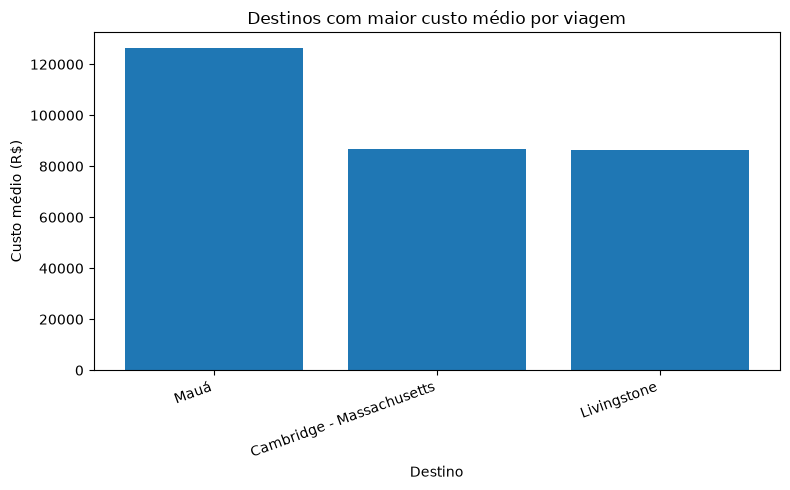

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    destinos["cidade_destino_ida"],
    destinos["custo_medio"]
)

plt.title("Destinos com maior custo médio por viagem")
plt.xlabel("Destino")
plt.ylabel("Custo médio (R$)")
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

**Interpretação**

Os destinos apresentados possuem o maior custo médio por viagem. Esse resultado pode refletir fatores como distância, disponibilidade de voos, diárias ou características específicas das missões realizadas nesses locais.

## Pergunta 3

### Qual foi a viagem de maior duração e qual foi seu custo total?

In [23]:
SQL_MAIOR_DURACAO = """
SELECT
    id_viagem,
    nome_orgao_superior,
    duracao_dias,
    valor_total
FROM silver_viagem
ORDER BY duracao_dias DESC
LIMIT 1
"""

maior_duracao = consultar(SQL_MAIOR_DURACAO)
maior_duracao

C:\Users\jpaul\AppData\Local\Temp\ipykernel_21264\3995570613.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,id_viagem,nome_orgao_superior,duracao_dias,valor_total
0,0000000000020699856,Ministério da Previdência Social,383,0.0


**Interpretação**

A consulta identifica a viagem com maior duração registrada, juntamente com seu custo total e o órgão responsável. Essa informação pode auxiliar na identificação de deslocamentos excepcionais ou de longa permanência.

## Pergunta 4

### Qual o meio de transporte mais utilizado nos trechos?

In [24]:
SQL_TRANSPORTE = """
SELECT
    meio_transporte,
    COUNT(*) AS quantidade
FROM silver_trecho
WHERE meio_transporte IS NOT NULL
  AND TRIM(meio_transporte) <> ''
GROUP BY meio_transporte
ORDER BY quantidade DESC
"""

transportes = consultar(SQL_TRANSPORTE)
transportes

C:\Users\jpaul\AppData\Local\Temp\ipykernel_21264\3995570613.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,meio_transporte,quantidade
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481


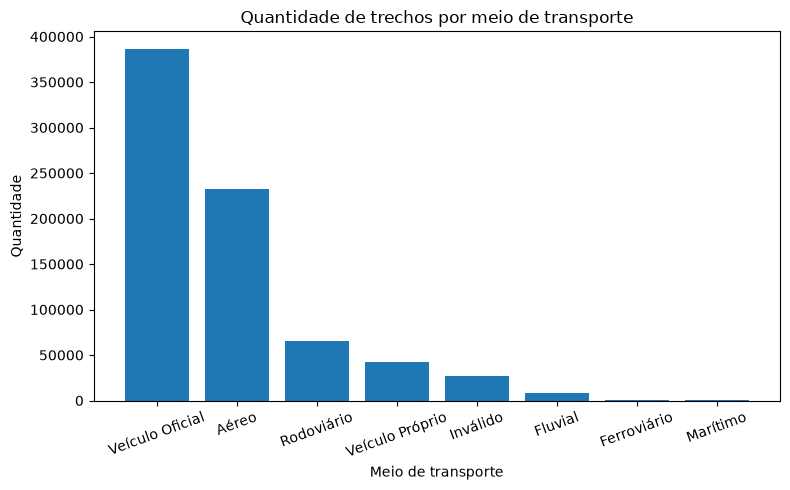

In [25]:
plt.figure(figsize=(8,5))

plt.bar(
    transportes["meio_transporte"],
    transportes["quantidade"]
)

plt.title("Quantidade de trechos por meio de transporte")
plt.xlabel("Meio de transporte")
plt.ylabel("Quantidade")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

**Interpretação**

O gráfico evidencia quais meios de transporte são mais utilizados nos deslocamentos oficiais, permitindo compreender o perfil logístico das viagens.

## Pergunta 5

### Qual UF aparece com maior frequência como destino?

In [26]:
SQL_DESTINO_UF = """
SELECT
    destino_uf,
    COUNT(*) AS quantidade
FROM silver_trecho
WHERE destino_uf IS NOT NULL
  AND TRIM(destino_uf) <> ''
GROUP BY destino_uf
ORDER BY quantidade DESC
"""

ufs = consultar(SQL_DESTINO_UF)
ufs

C:\Users\jpaul\AppData\Local\Temp\ipykernel_21264\3995570613.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,destino_uf,quantidade
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603
5,Pará,40044
6,Rio Grande do Sul,38684
7,Mato Grosso do Sul,30516
8,Bahia,28375
9,Pernambuco,28372


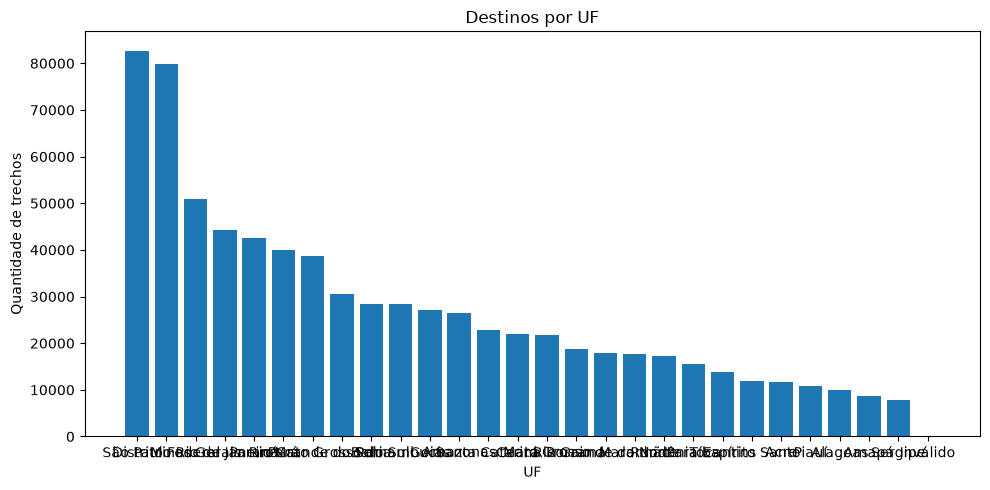

In [27]:
plt.figure(figsize=(10,5))

plt.bar(
    ufs["destino_uf"],
    ufs["quantidade"]
)

plt.title("Destinos por UF")
plt.xlabel("UF")
plt.ylabel("Quantidade de trechos")

plt.tight_layout()
plt.show()

**Interpretação**

A distribuição das UFs de destino mostra quais estados concentram a maior parte dos deslocamentos realizados.

## Pergunta 4.2

### Qual tipo de pagamento apresenta o maior valor médio?

In [28]:
SQL_TIPO_PAGAMENTO = """
SELECT
    tipo_pagamento,
    SUM(valor_total) AS valor_total,
    SUM(quantidade_pagamentos) AS quantidade_pagamentos,
    SUM(valor_total) / SUM(quantidade_pagamentos) AS valor_medio
FROM gold_pagamentos_orgao
GROUP BY tipo_pagamento
ORDER BY valor_medio DESC
"""

tipos_pagamento = consultar(SQL_TIPO_PAGAMENTO)
tipos_pagamento

C:\Users\jpaul\AppData\Local\Temp\ipykernel_21264\3995570613.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,tipo_pagamento,valor_total,quantidade_pagamentos,valor_medio
0,DIÁRIAS,8.343526e+08,401463.0,2078.280299
1,PASSAGEM,3.549789e+08,188985.0,1878.344393
2,Serviço correlato: seguro,2.190137e+06,4894.0,447.514653
3,RESTITUIÇÃO,2.843762e+06,11574.0,245.702610


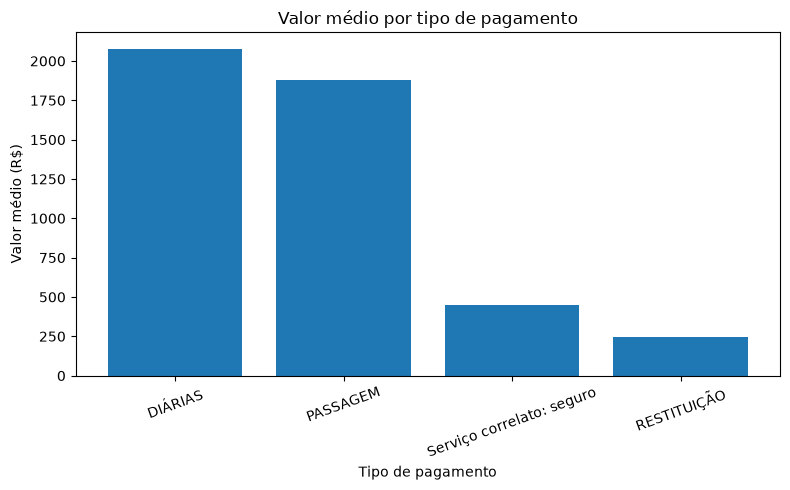

In [29]:
plt.figure(figsize=(8,5))

plt.bar(
    tipos_pagamento["tipo_pagamento"],
    tipos_pagamento["valor_medio"]
)

plt.title("Valor médio por tipo de pagamento")
plt.xlabel("Tipo de pagamento")
plt.ylabel("Valor médio (R$)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

**Interpretação**

A análise evidencia quais modalidades de pagamento apresentam maior desembolso médio por ocorrência, permitindo identificar despesas potencialmente mais relevantes.

## Pergunta 7

### Qual órgão pagador concentrou o maior volume de pagamentos?

In [30]:
SQL_ORGAO_PAGADOR = """
SELECT
    nome_orgao_pagador,
    SUM(valor_total) AS valor_total
FROM gold_pagamentos_orgao
GROUP BY nome_orgao_pagador
ORDER BY valor_total DESC
LIMIT 10
"""

orgaos_pagadores = consultar(SQL_ORGAO_PAGADOR)
orgaos_pagadores

C:\Users\jpaul\AppData\Local\Temp\ipykernel_21264\3995570613.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,nome_orgao_pagador,valor_total
0,Fundo Nacional de Segurança Pública,2.784810e+08
1,Sigiloso,2.004848e+08
2,Comando da Aeronáutica,8.176914e+07
3,Instituto Nacional do Seguro Social,3.742760e+07
4,Comando do Exército,3.687264e+07
5,Ministério da Gestão e da Inovação em Serviços...,3.554176e+07
6,Instituto Brasileiro do Meio Ambiente e dos Re...,3.158985e+07
7,Ministério das Relações Exteriores - Unidades ...,2.560538e+07
8,Receita Federal do Brasil,2.381103e+07
9,Ministério da Agricultura e Pecuária - Unidade...,2.289988e+07


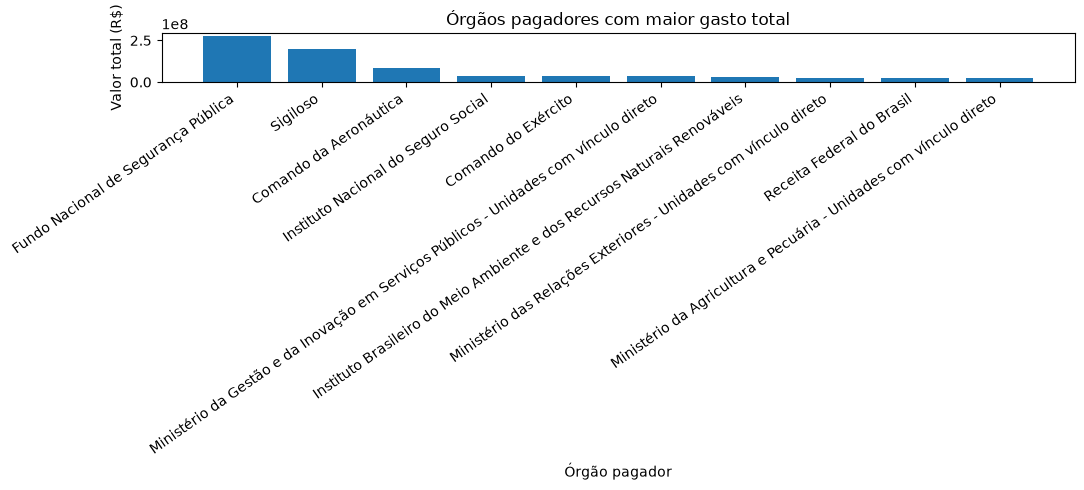

In [31]:
plt.figure(figsize=(11,5))

plt.bar(
    orgaos_pagadores["nome_orgao_pagador"],
    orgaos_pagadores["valor_total"]
)

plt.title("Órgãos pagadores com maior gasto total")
plt.xlabel("Órgão pagador")
plt.ylabel("Valor total (R$)")

plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.show()

**Interpretação**

O gráfico mostra os órgãos pagadores responsáveis pelos maiores desembolsos com viagens, permitindo identificar onde se concentram os maiores volumes financeiros.

In [6]:
conexao.close()

print("Conexão com o MySQL encerrada.")

Conexão com o MySQL encerrada.
